In [26]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression

In [27]:

df = pd.read_excel("student_habits_performance.xlsx")

In [3]:
# NUmber of row in the missing in the columns.Answer provided in the  ascending order.
student_habits_performance = df.isnull().sum().sort_values(ascending=False)

In [4]:
# Ascending=False = sort from most nulls to fewest
# Ascending=True = sort from fewest nulls to most
print(student_habits_performance)

parental_education_level         91
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [5]:
# The % of missing values in each column, shown to 2 decimal places
for column in df.columns:
    percentage = df[column].isnull().mean() * 100
    print(f"{column}: {percentage:.2f}%")

student_id: 0.00%
age: 0.00%
gender: 0.00%
study_hours_per_day: 0.00%
social_media_hours: 0.00%
netflix_hours: 0.00%
part_time_job: 0.00%
attendance_percentage: 0.00%
sleep_hours: 0.00%
diet_quality: 0.00%
exercise_frequency: 0.00%
parental_education_level: 9.10%
internet_quality: 0.00%
mental_health_rating: 0.00%
extracurricular_participation: 0.00%
exam_score: 0.00%


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [7]:
# Removing 'parental_education_level' because it may introduce bias,
# adds pressure on students, and has 9% missing values.
df = df.drop(columns=['parental_education_level'], errors='ignore')

In [8]:
if 'parental_education_level' in df.columns:
    print("Column still exists.")
else:
    print("Column successfully deleted.")

Column successfully deleted.


In [9]:
#Trimming all the spaces that i can not see with my naked eye.
df.columns = df.columns.str.strip()

In [10]:
#Checking for any N/A values in the dataset.
if df.isnull().values.any():
    print("The are still N/A values in the dataset.")

In [11]:
#Where in the dataset are the missing values?
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [12]:
# Finding duplicates in the  the dataset.
duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

Number of duplicated rows: 0


In [13]:
df.duplicated().any()

np.False_

In [14]:
df.describe()


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [15]:
# Validate data ranges.
def validate_range(df, column, min_val, max_val):
    return df[(df[column] < min_val) | (df[column] > max_val)]

print(validate_range(df, 'age', 17, 24))
print(validate_range(df, 'study_hours_per_day', 0, 9))
print(validate_range(df, 'social_media_hours', 0, 8))
print(validate_range(df, 'netflix_hours', 0, 6))
print(validate_range(df, 'attendance_percentage', 8, 100))
print(validate_range(df, 'sleep_hours', 0, 10))
print(validate_range(df, 'exercise_frequency', 2, 8))

Empty DataFrame
Columns: [student_id, age, gender, study_hours_per_day, social_media_hours, netflix_hours, part_time_job, attendance_percentage, sleep_hours, diet_quality, exercise_frequency, internet_quality, mental_health_rating, extracurricular_participation, exam_score]
Index: []
Empty DataFrame
Columns: [student_id, age, gender, study_hours_per_day, social_media_hours, netflix_hours, part_time_job, attendance_percentage, sleep_hours, diet_quality, exercise_frequency, internet_quality, mental_health_rating, extracurricular_participation, exam_score]
Index: []
Empty DataFrame
Columns: [student_id, age, gender, study_hours_per_day, social_media_hours, netflix_hours, part_time_job, attendance_percentage, sleep_hours, diet_quality, exercise_frequency, internet_quality, mental_health_rating, extracurricular_participation, exam_score]
Index: []
Empty DataFrame
Columns: [student_id, age, gender, study_hours_per_day, social_media_hours, netflix_hours, part_time_job, attendance_percentage, 

In [16]:
# mean/ median per mental health grouping-

class StudentAnalyzer:

    def __init__(self, data: pd.DataFrame):
        expected = {'mental_health_ratings', 'study_hours_per_day'}
        if not expected.issubset(data.columns):
            missing = expected - set(data.columns)
            raise ValueError(f"Missing required columns: {missing}")
        self.data = data.copy()


    def mean_study_by_mental_health(self) -> pd.Series:
        return (self.data
                  .groupby('mental_health_ratings')['study_hours_per_day']
                  .mean()
                  .sort_index())

    def median_study_by_mental_health(self) -> pd.Series:
        return (self.data
                  .groupby('mental_health_ratings')['study_hours_per_day']
                  .median()
                  .sort_index())
if __name__ == "__main__":
    np.random.seed(42)                          # makes demo reproducible
    df = pd.DataFrame({
        "mental_health_ratings": np.random.randint(1, 11, size=1000),
        "study_hours_per_day":  np.random.uniform(0.0, 7.4, size=1000).round(1)
    })

    analyzer = StudentAnalyzer(df)
 
    print("MEAN study hours by mental-health rating:")
    print(analyzer.mean_study_by_mental_health(), end="\n\n")

    print("MEDIAN study hours by mental-health rating:")
    print(analyzer.median_study_by_mental_health())

MEAN study hours by mental-health rating:
mental_health_ratings
1     3.816102
2     4.044578
3     3.946364
4     3.445745
5     3.692523
6     3.406250
7     3.672340
8     3.458000
9     4.025275
10    3.707477
Name: study_hours_per_day, dtype: float64

MEDIAN study hours by mental-health rating:
mental_health_ratings
1     3.90
2     4.30
3     4.40
4     3.40
5     3.70
6     3.30
7     3.75
8     3.50
9     4.30
10    3.50
Name: study_hours_per_day, dtype: float64


In [17]:
class StudentAnalyzer:
    def __init__(self, data: pd.DataFrame):
        expected = {'mental_health_ratings', 'study_hours_per_day'}
        if not expected.issubset(data.columns):
            missing = expected - set(data.columns)
            raise ValueError(f"Missing required columns: {missing}")
        self.data = data.copy()

    def mean_study_by_mental_health(self) -> pd.Series:
        return (self.data
                .groupby('mental_health_ratings')['study_hours_per_day']
                .mean()
                .sort_index())

    def median_study_by_mental_health(self) -> pd.Series:
        return (self.data
                .groupby('mental_health_ratings')['study_hours_per_day']
                .median()
                .sort_index())

if __name__ == "__main__":
    np.random.seed(42)  # makes demo reproducible
    df = pd.DataFrame({
        "mental_health_ratings": np.random.randint(1, 11, size=1000),
        "study_hours_per_day": np.random.uniform(0.0, 7.4, size=1000).round(1)
    })

    analyzer = StudentAnalyzer(df)

    print("MEAN study hours by mental health rating:")
    print(analyzer.mean_study_by_mental_health(), end="\n\n")

    print("MEDIAN study hours by mental health rating:")
    print(analyzer.median_study_by_mental_health())

MEAN study hours by mental health rating:
mental_health_ratings
1     3.816102
2     4.044578
3     3.946364
4     3.445745
5     3.692523
6     3.406250
7     3.672340
8     3.458000
9     4.025275
10    3.707477
Name: study_hours_per_day, dtype: float64

MEDIAN study hours by mental health rating:
mental_health_ratings
1     3.90
2     4.30
3     4.40
4     3.40
5     3.70
6     3.30
7     3.75
8     3.50
9     4.30
10    3.50
Name: study_hours_per_day, dtype: float64


In [18]:
# Calculate mean study hours per mental health rating group and round to 2 decimals
mean_study = df.groupby('mental_health_ratings')['study_hours_per_day'].mean().round(2)

# Calculate median study hours per mental health rating group and round to 2 decimals
median_study = df.groupby('mental_health_ratings')['study_hours_per_day'].median().round(2)

print("Mean study hours per mental health rating:")
print(mean_study)

print("\nMedian study hours per mental health rating:")
print(median_study)

# Findings for Mean:
# Students with better mental health ratings tend to study a bit more on average,
# but the difference is small.

# Findings for Median:
# Median values support the mean trend, showing slight variation across ratings.

Mean study hours per mental health rating:
mental_health_ratings
1     3.82
2     4.04
3     3.95
4     3.45
5     3.69
6     3.41
7     3.67
8     3.46
9     4.03
10    3.71
Name: study_hours_per_day, dtype: float64

Median study hours per mental health rating:
mental_health_ratings
1     3.90
2     4.30
3     4.40
4     3.40
5     3.70
6     3.30
7     3.75
8     3.50
9     4.30
10    3.50
Name: study_hours_per_day, dtype: float64


In [61]:
import pandas as pd

# Load your data
df = pd.read_excel("student_habits_performance.xlsx")

# Normalize column names: strip spaces, lowercase, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Calculate correlation
r = df['sleep_hours'].corr(df['exam_score'])

print(f"Correlation between sleep_hours and exam_score: {r:.3f}")

# Simple interpretation
if r > 0.5:
    print("There is a strong positive correlation: more sleep_hours tend to associate with higher exam_score.")
elif r > 0.3:
    print("There is a moderate positive correlation between sleep_hours and exam_score.")
elif r > 0:
    print("There is a weak positive correlation between sleep_hours and exam_score.")
elif r == 0:
    print("There is no correlation between sleep_hours and exam_score.")
elif r > -0.3:
    print("There is a weak negative correlation between sleep_hours and exam_score.")
elif r > -0.5:
    print("There is a moderate negative correlation between sleep_hours and exam_score.")
else:
    print("There is a strong negative correlation: more sleep_hours tend to associate with lower exam_score.")


Correlation between sleep_hours and exam_score: 0.122
There is a weak positive correlation between sleep_hours and exam_score.


In [ ]:
# We use the IQR to find outliers.
# IQR = Q3 − Q1

# Quartiles 
Q1 = round(df["social_media_hours"].quantile(0.25), 2)
Q3 = round(df["social_media_hours"].quantile(0.75), 2)

# IQR
IQR = round(Q3 - Q1, 2)

# Limits
lower_limit = round(Q1 - 1.5 * IQR, 2)
upper_limit = round(Q3 + 1.5 * IQR, 2)

# Outliers
outliers = df[
    (df["social_media_hours"] < lower_limit) |
    (df["social_media_hours"] > upper_limit)
]

print("Outlier limits:", lower_limit, "to", upper_limit)
print("Number of outliers:", len(outliers))

Outlier limits: -0.7 to 5.7
Number of outliers: 4


In [ ]:
import pandas as pd

# Correct path to your Excel file
file_path = r"C:\Users\mhlon\Desktop\student_workspace\student_data_analysis\student_habits_performance.xlsx"

try:
    df = pd.read_excel(file_path)
    print("File loaded successfully.")
    print(df.head())  # Show first few rows to verify
except FileNotFoundError:
    print("File not found! Double-check the path and file name.")

File loaded successfully.
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                  

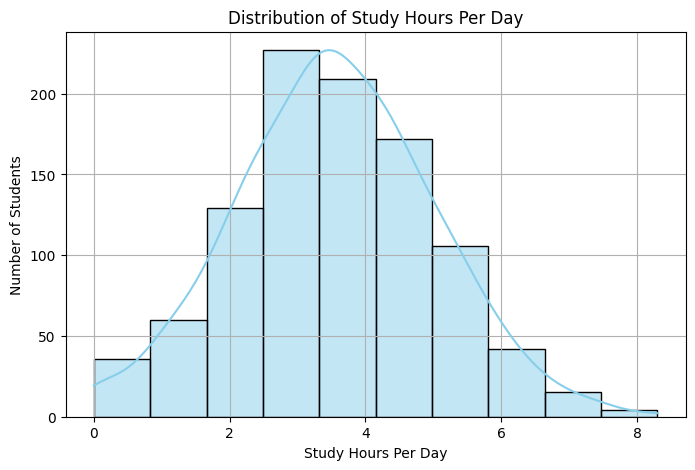

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['study_hours_per_day'], bins=10, kde=True, color='skyblue')

plt.title('Distribution of Study Hours Per Day')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Number of Students')

plt.grid(True)
plt.show()

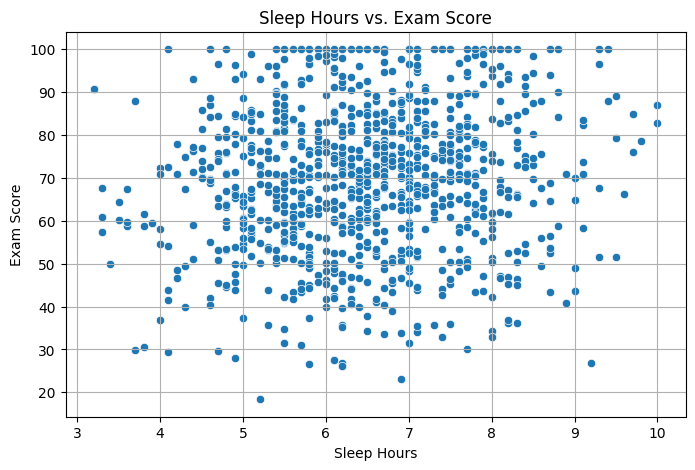

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['sleep_hours'], y=df['exam_score'])

plt.title('Sleep Hours vs. Exam Score')
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')

plt.grid(True)
plt.show()

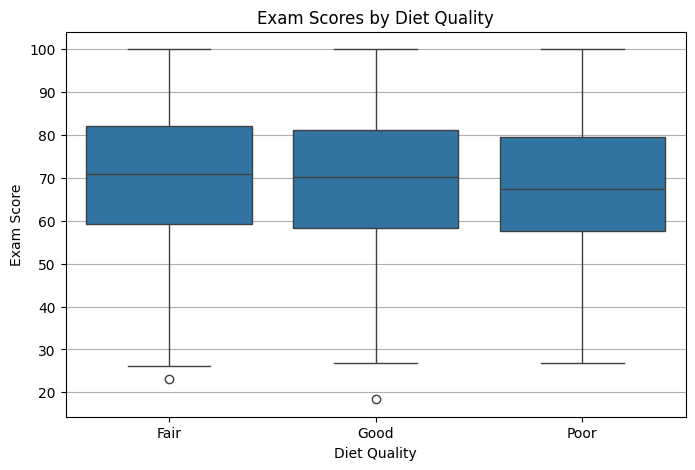

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['diet_quality'], y=df['exam_score'])

plt.title('Exam Scores by Diet Quality')
plt.xlabel('Diet Quality')
plt.ylabel('Exam Score')
plt.grid(True, axis='y')
plt.show()

In [60]:
required_columns = [
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating',
    'extracurricular_participation',
    'internet_quality',
    'part_time_job',
    'exam_score'
]

missing_cols = [col for col in required_columns if col not in df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are present.")

All required columns are present.


In [39]:
df = pd.read_excel(r"C:\Users\mhlon\Desktop\student_workspace\student_data_analysis\student_habits_performance.xlsx")

In [30]:
# Column: extracurricular_participation
# Kids should play and be active — moving the body helps the brain grow and develop.
# So, I had convert extracurricular participation (Yes/No) into numbers (1/0) for the model.
# Convert 'Yes'/'No' to 1/0 only if the column exists
if 'extracurricular_participation' in df.columns:
    df['extracurricular_participation_score'] = df['extracurricular_participation'].map({'Yes': 1, 'No': 0})
    print(df[['extracurricular_participation', 'extracurricular_participation_score']].head())
else:
    print("Column missing: extracurricular_participation")

  extracurricular_participation  extracurricular_participation_score
0                           Yes                                    1
1                            No                                    0
2                            No                                    0
3                           Yes                                    1
4                            No                                    0


In [31]:
#The new generation always needs their phones, and internet connection issues affect both study time and mental health, causing frustration.
# Map internet quality to numeric values
df['internet_quality'] = df['internet_quality'].replace('Average', 'Fair')

# Map internet quality to scores
internet_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2
}

df['internet_quality_score'] = df['internet_quality'].map(internet_map)

# Print the updated columns to verify
print(df[['internet_quality', 'internet_quality_score']].head(10))

  internet_quality  internet_quality_score
0             Fair                       1
1             Fair                       1
2             Poor                       0
3             Good                       2
4             Good                       2
5             Fair                       1
6             Poor                       0
7             Fair                       1
8             Good                       2
9             Good                       2


In [32]:
# Having a part-time job can drain a student’s energy and reduce study time.
# Jobs are not equal — some are more demanding than others.
# We convert part-time job (Yes/No) into numbers (1/0) to help the model understand this impact.
df['part_time_job_score'] = df['part_time_job'].map({'Yes': 1, 'No': 0})
print(df[['part_time_job', 'part_time_job_score']].head())

  part_time_job  part_time_job_score
0            No                    0
1            No                    0
2            No                    0
3            No                    0
4            No                    0


In [33]:
import pandas as pd

features = [
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating',
    'extracurricular_participation_score',
    'internet_quality_score',
    'part_time_job_score'
]

# Check data types of each feature column
non_numeric = []
for col in features:
    if not pd.api.types.is_numeric_dtype(df[col]):
        non_numeric.append(col)

if non_numeric:
    print("These columns are NOT numeric and need conversion:")
    print(non_numeric)
else:
    print("All feature columns are numeric. You’re good to go!")

All feature columns are numeric. You’re good to go!


In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load
df = pd.read_excel("student_habits_performance.xlsx")

# 2. Robust mapping
maps = {
    'extracurricular_participation': {'Yes': 1, 'No': 0},
    'internet_quality': {'Poor': 0, 'Fair': 1, 'Good': 2},
    'part_time_job': {'Yes': 1, 'No': 0}
}
for col, d in maps.items():
    df[f"{col}_score"] = df[col].map(d).fillna(-1)  # ← avoids NaNs

# 3. Feature set
features = [
    'study_hours_per_day', 'social_media_hours', 'netflix_hours',
    'attendance_percentage', 'sleep_hours', 'exercise_frequency',
    'mental_health_rating',
    'extracurricular_participation_score',
    'internet_quality_score',
    'part_time_job_score'
]
features = [f for f in features if f in df.columns]

# 4. Split, train, predict
X = df[features]
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression().fit(X_train, y_train)
df['predicted_score'] = model.predict(X).round(2)

print(f"R²:  {r2_score(y_test, model.predict(X_test)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, model.predict(X_test)):.2f}")

R²:  0.900
MAE: 4.11


In [36]:
print(df[features].dtypes)

study_hours_per_day                    float64
social_media_hours                     float64
netflix_hours                          float64
attendance_percentage                  float64
sleep_hours                            float64
exercise_frequency                       int64
mental_health_rating                     int64
extracurricular_participation_score      int64
internet_quality_score                 float64
part_time_job_score                      int64
dtype: object


In [43]:
features = [
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating',
    'extracurricular_participation_score',
    'internet_quality_score',
    'part_time_job_score'
]

expected = {
    'study_hours_per_day': 1,
    'social_media_hours': -1,
    'netflix_hours': -1,
    'attendance_percentage': 1,
    'sleep_hours': 1,
    'exercise_frequency': 1,
    'mental_health_rating': 1,
    'extracurricular_participation_score': -1,
    'internet_quality_score': -1,
    'part_time_job_score': -1
}

print("Feature                         Coef  Sign Match")
for f, c in zip(features, model.coef_):
    sign = np.sign(c)
    match = "✅" if sign == expected[f] else "❌"
    print(f"{f:<30} {c:6.2f} {int(sign):4d} {match}")

mask = np.ones(len(df), dtype=bool)
for f, d in expected.items():
    med = df[f].median()
    if d == 1:
        mask &= df[f] >= med
    else:
        mask &= df[f] <= med

good_avg = df.loc[mask, 'exam_score'].mean()
bad_avg = df.loc[~mask, 'exam_score'].mean()

print(f"\nGood habit avg score: {good_avg:.2f}")
print(f"Other students avg:  {bad_avg:.2f}")
print("✅ Good habits group scores higher" if good_avg > bad_avg else "❌ Good habits group scores lower")

Feature                         Coef  Sign Match
study_hours_per_day              9.66    1 ✅
social_media_hours              -2.54   -1 ✅
netflix_hours                   -2.20   -1 ✅
attendance_percentage            0.11    1 ✅
sleep_hours                      1.99    1 ✅
exercise_frequency               1.55    1 ✅
mental_health_rating             1.99    1 ✅
extracurricular_participation_score  -0.15   -1 ✅
internet_quality_score          -0.18   -1 ✅
part_time_job_score             -0.11   -1 ✅

Good habit avg score: 100.00
Other students avg:  68.88
✅ Good habits group scores higher


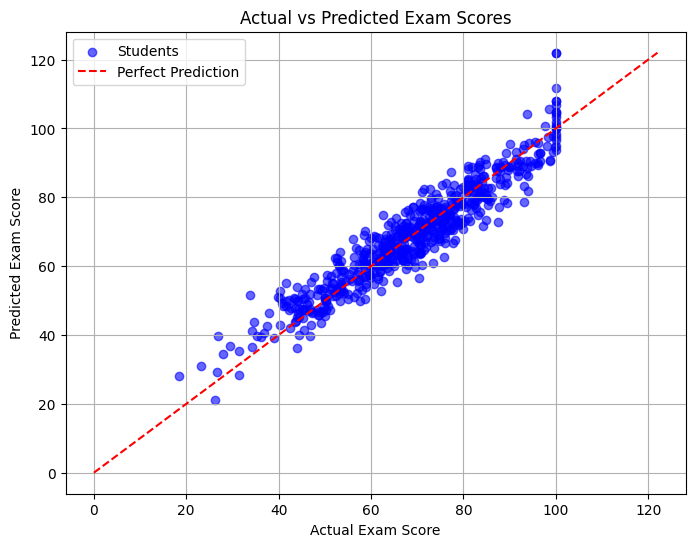

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot actual vs predicted
plt.scatter(df['exam_score'], df['predicted_score'], color='blue', alpha=0.6, label='Students')

# Reference line: perfect prediction (y = x)
max_score = max(df['exam_score'].max(), df['predicted_score'].max())
plt.plot([0, max_score], [0, max_score], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def good_exam_score_advice():
    advice = [
        "📚 Increase your study hours per day.",
        "📵 Reduce time spent on social media.",
        "📺 Limit Netflix hours.",
        "🏫 Attend classes regularly (high attendance percentage).",
        "😴 Get enough sleep (more sleep helps).",
        "🏃 Exercise regularly to improve focus and health.",
        "😊 Take care of your mental health.",
        "🎯 Participate less in extracurricular activities (to focus more).",
        "🔌 Use quality internet wisely (avoid distractions).",
        "⏳ Limit part-time job hours to focus on studying."
    ]
    
    print("To improve your exam scores, try to follow these habits:\n")
    for tip in advice:
        print(tip)

# Call the function to print advice
good_exam_score_advice()

To improve your exam scores, try to follow these habits:

📚 Increase your study hours per day.
📵 Reduce time spent on social media.
📺 Limit Netflix hours.
🏫 Attend classes regularly (high attendance percentage).
😴 Get enough sleep (more sleep helps).
🏃 Exercise regularly to improve focus and health.
😊 Take care of your mental health.
🎯 Participate less in extracurricular activities (to focus more).
🔌 Use quality internet wisely (avoid distractions).
⏳ Limit part-time job hours to focus on studying.


In [58]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from pathlib import Path

# 1. Load data (original file stays unchanged)
df = pd.read_excel("student_habits_performance.xlsx")

# 2. Map categorical → numeric, filling unknowns with -1
maps = {
    'extracurricular_participation': {'Yes': 1, 'No': 0},
    'internet_quality': {'Poor': 0, 'Fair': 1, 'Good': 2},
    'part_time_job': {'Yes': 1, 'No': 0}
}
for col, d in maps.items():
    score_col = f"{col}_score"
    if score_col not in df.columns:
        df[score_col] = df[col].map(d).fillna(-1)

# 3. Feature list (only keep those that exist)
features = [
    'study_hours_per_day', 'social_media_hours', 'netflix_hours',
    'attendance_percentage', 'sleep_hours', 'exercise_frequency',
    'mental_health_rating',
    'extracurricular_participation_score',
    'internet_quality_score',
    'part_time_job_score'
]
features = [f for f in features if f in df.columns]

# 4. Train model on full data and add predictions
model = LinearRegression().fit(df[features], df['exam_score'])
df['predicted_score'] = model.predict(df[features]).round(2)

# 5. Preview so you can confirm the new column
pd.set_option('display.max_columns', None)   # show all columns once
print("Preview with predicted_score:")
print(df[features + ['exam_score', 'predicted_score']].head())
print(f"\nRows in output: {len(df):,}")

# 6. Save to CSV (new file, original XLSX untouched)
output_cols = features + ['exam_score', 'predicted_score']
out_file = Path.cwd() / "model_expected_features_with_scores.csv"
df.to_csv(out_file, columns=output_cols, index=False)
print(f"\n✅ CSV saved to: {out_file.resolve()}")

Preview with predicted_score:
   study_hours_per_day  social_media_hours  netflix_hours  \
0                  0.0                 1.2            1.1   
1                  6.9                 2.8            2.3   
2                  1.4                 3.1            1.3   
3                  1.0                 3.9            1.0   
4                  5.0                 4.4            0.5   

   attendance_percentage  sleep_hours  exercise_frequency  \
0                   85.0          8.0                   6   
1                   97.3          4.6                   6   
2                   94.8          8.0                   1   
3                   71.0          9.2                   4   
4                   90.9          4.9                   3   

   mental_health_rating  extracurricular_participation_score  \
0                     8                                    1   
1                     8                                    0   
2                     1                     